# Annotating regions in `SpatialData` objects

Regions of interest in a `SpatialData` object are stored as shapes: polygons living in a coordinate system, alongside the images and tables they annotate. Once a region exists as a shape, we can query the object with it, subset every element it overlaps, and write the result back onto the table.

The polygons below are hard-coded so the notebook runs the same way for everybody. In your own work you would usually draw them on top of the image in an interactive viewer and read them back out as shapes.

⚠️ Adjust the variable below to the data path on your specific workstation.

In [1]:
data_path = "../data/"

In [ ]:
import spatialdata as sd
import spatialdata_plot as sdp
import matplotlib.pyplot as plt
import pandas as pd

for p in [sd, sdp]:
    print(f"{p.__name__}: {p.__version__}")

sdata_visium = sd.read_zarr(data_path + "visium.zarr")
sdata_visium

## Interactively explore and annotate the data

In [12]:
# The regions below were drawn once on the image and stored here verbatim,
# so that the rest of the notebook is reproducible.
import geopandas as gpd
from shapely.geometry import Polygon

# fmt: off
coords1 = [
    (137, 553), (137, 486), (139, 465), (139, 445), (142, 410), (142, 387),
    (146, 352), (162, 345), (180, 345), (197, 343), (237, 343), (254, 347),
    (289, 363), (300, 377), (304, 393), (302, 410), (287, 418), (267, 425),
    (254, 437), (254, 455), (264, 470), (272, 487), (285, 502), (299, 515),
    (310, 530), (315, 548), (319, 565), (304, 577), (260, 582), (239, 582),
    (222, 575), (202, 572), (185, 570), (137, 553)
]
coords2 = [
    (722, 443), (705, 438), (688, 430), (655, 407), (642, 390), (630, 372),
    (620, 353), (612, 335), (605, 295), (603, 279), (603, 259), (605, 240),
    (618, 222), (658, 179), (690, 157), (705, 149), (723, 140), (757, 120),
    (775, 115), (817, 112), (837, 114), (857, 114), (895, 117), (935, 125),
    (955, 134), (970, 144), (1000, 170), (1015, 180), (1028, 192), (1045, 202),
    (1051, 219), (1055, 235), (1055, 257), (1053, 277), (1050, 293), (1030, 360),
    (1023, 377), (1018, 393), (1003, 407), (995, 423), (985, 438), (968, 445),
    (951, 450), (928, 455), (891, 458), (852, 458), (752, 450), (722, 443)
]
coords3 = [
    (1474, 1594), (1458, 1601), (1439, 1604), (1421, 1604), (1404, 1596),
    (1399, 1579), (1399, 1561), (1408, 1546), (1419, 1531), (1451, 1511),
    (1464, 1499), (1479, 1487), (1496, 1481), (1511, 1491), (1526, 1502),
    (1531, 1519), (1474, 1594)
]
# fmt: on

poly1 = Polygon(coords1)
poly2 = Polygon(coords2)
poly3 = Polygon(coords3)
gdf = sd.models.ShapesModel.parse(
    gpd.GeoDataFrame({"geometry": [poly1, poly2, poly3]}),
    transformations={"downscaled_hires": sd.transformations.Identity()},
)

sdata_visium["ifi6_hotspots"] = gdf

## Inspect the shape we just created

In [13]:
sdata_visium

SpatialData object, with associated Zarr store: /Users/macbook/embl/projects/basel/spatialdata-workshops/data/visium.zarr
├── Images
│     ├── 'CytAssist_FFPE_Protein_Expression_Human_Glioblastoma_hires_image': DataArray[cyx] (3, 2000, 1744)
│     └── 'CytAssist_FFPE_Protein_Expression_Human_Glioblastoma_lowres_image': DataArray[cyx] (3, 600, 523)
├── Shapes
│     ├── 'CytAssist_FFPE_Protein_Expression_Human_Glioblastoma': GeoDataFrame shape: (5756, 2) (2D shapes)
│     ├── 'Shapes': GeoDataFrame shape: (3, 1) (2D shapes)
│     └── 'ifi6_hotspots': GeoDataFrame shape: (3, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (5756, 18085)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        CytAssist_FFPE_Protein_Expression_Human_Glioblastoma_hires_image (Images), CytAssist_FFPE_Protein_Expression_Human_Glioblastoma (Shapes), Shapes (Shapes), ifi6_hotspots (Shapes)
    ▸ 'downscaled_lowres', with elements:
        CytAssist_FFPE_Protein_Expression_Human_Glioblastoma

In [ ]:
(
    sdata_visium.pl.render_images()
    .pl.render_shapes(
        "ifi6_hotspots",
        outline_alpha=1,
        fill_alpha=0.5,
    )
    .pl.show("downscaled_hires")
)

## Use the annotated shape to extract a subpopulation

In [15]:
from spatialdata import polygon_query

polygon = sdata_visium["ifi6_hotspots"].geometry.iloc[0]
filtered_sdata = polygon_query(
    sdata_visium, polygon=polygon, target_coordinate_system="downscaled_hires"
)
filtered_sdata

SpatialData object
├── Images
│     └── 'CytAssist_FFPE_Protein_Expression_Human_Glioblastoma_hires_image': DataArray[cyx] (3, 239, 182)
├── Shapes
│     ├── 'CytAssist_FFPE_Protein_Expression_Human_Glioblastoma': GeoDataFrame shape: (95, 2) (2D shapes)
│     ├── 'Shapes': GeoDataFrame shape: (1, 1) (2D shapes)
│     └── 'ifi6_hotspots': GeoDataFrame shape: (1, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (95, 18085)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        CytAssist_FFPE_Protein_Expression_Human_Glioblastoma_hires_image (Images), CytAssist_FFPE_Protein_Expression_Human_Glioblastoma (Shapes), Shapes (Shapes), ifi6_hotspots (Shapes)
    ▸ 'downscaled_lowres', with elements:
        CytAssist_FFPE_Protein_Expression_Human_Glioblastoma (Shapes)
    ▸ 'global', with elements:
        CytAssist_FFPE_Protein_Expression_Human_Glioblastoma (Shapes)

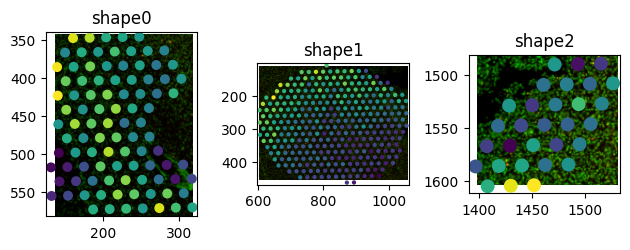

In [16]:
from spatialdata import polygon_query

fig, axs = plt.subplots(1, 3)

idx_in_selection = []

for shape in range(3):

    polygon = sdata_visium["ifi6_hotspots"].geometry.iloc[shape]
    filtered_sdata = polygon_query(
        sdata_visium, polygon=polygon, target_coordinate_system="downscaled_hires"
    )
    filtered_sdata.pl.render_images().pl.render_shapes(
        element="CytAssist_FFPE_Protein_Expression_Human_Glioblastoma",
        color="MT-CO2",
    ).pl.show("downscaled_hires", ax=axs[shape], colorbar=False, title=f"shape{shape}")

    # store names of spots within our 3 selections
    idx_in_selection.extend(filtered_sdata.tables["table"].obs.index.tolist())

plt.tight_layout()

## Use the subpopulation to annotate the original data

In [17]:
idx_in_selection[:3]

['AACTGCCGCTACATCT-1', 'ACAGAATCATACCTTC-1', 'ACATAAGACAGAGCAT-1']

In [18]:
sdata_visium.tables["table"].obs["annotation"] = ""

sdata_visium.tables["table"].obs.loc[idx_in_selection, "annotation"] = "IFI6 Hotspot"

INFO     Rasterizing image for faster rendering.                                                                   


/Users/macbook/embl/projects/basel/spatialdata-plot/src/spatialdata_plot/pl/basic.py:879: UserWarning: Converting copy of 'annotation' column to categorical dtype for categorical plotting. Consider converting before plotting.
  _render_shapes(
/Users/macbook/embl/projects/basel/spatialdata-plot/src/spatialdata_plot/pl/utils.py:782: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


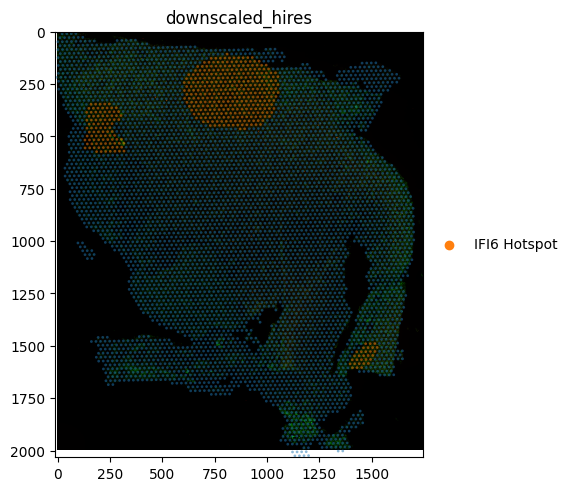

In [19]:
sdata_visium.pl.render_images().pl.render_shapes(
    element="CytAssist_FFPE_Protein_Expression_Human_Glioblastoma",
    color="annotation",
    fill_alpha=0.5,
).pl.show("downscaled_hires")